In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

## Question 1 | Data Loading and Initial Exploration
**(a) Load the dataset and display the first 10 and last 5 rows. Identify the target variable.**

In [58]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
           'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
           'hours_per_week', 'native_country', 'income']
df = pd.read_csv(url, names=columns, na_values=[' ?', '?'])

# Introduce missing values artificially to meet assignment requirements (at least 3 columns)
np.random.seed(42)
df.loc[df.sample(frac=0.05).index, 'age'] = np.nan
df.loc[df.sample(frac=0.05).index, 'hours_per_week'] = np.nan
df.loc[df.sample(frac=0.05).index, 'capital_gain'] = np.nan

# Introduce outliers artificially (if needed, though capital_gain already has outliers)
df.loc[df.sample(n=10).index, 'age'] = df['age'].mean() + 10 * df['age'].std()

print("First 10 rows:")
display(df.head(10))
print("\nLast 5 rows:")
display(df.tail(5))

First 10 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0,40.0,Cuba,<=50K
5,37.0,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,NaN,0,40.0,United-States,<=50K
6,49.0,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0.0,0,16.0,Jamaica,<=50K
7,52.0,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0,45.0,United-States,>50K
8,31.0,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084.0,0,50.0,United-States,>50K
9,42.0,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178.0,0,40.0,United-States,>50K



Last 5 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27.0,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0,38.0,United-States,<=50K
32557,40.0,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0,40.0,United-States,>50K
32558,58.0,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0,40.0,United-States,<=50K
32559,22.0,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0.0,0,20.0,United-States,<=50K
32560,52.0,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024.0,0,40.0,United-States,>50K


**Observation**: The dataset has been loaded. The target variable is `income` (binary: <=50K or >50K). Missing values were artificially introduced in `age`, `hours_per_week`, and `capital_gain` to satisfy the requirements.

**(b) Report the shape, and the number of numerical and categorical columns.**

In [59]:
print(f"Dataset Shape: {df.shape}")
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
print(f"Number of numerical columns: {len(num_cols)}")
print(f"Number of categorical columns: {len(cat_cols)}")

Dataset Shape: (32561, 15)
Number of numerical columns: 6
Number of categorical columns: 9


**Observation**: The dataset contains 32561 rows and 15 columns. There are 6 numerical and 9 categorical columns (including the target).

**(c) Use info() to check data types and non-null counts. Correct any wrong data types.**

In [60]:
df.info()

# Strip whitespace from string columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert target variable to categorical
df['income'] = df['income'].astype('category')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             30933 non-null  float64
 1   workclass       30725 non-null  object 
 2   fnlwgt          32561 non-null  int64  
 3   education       32561 non-null  object 
 4   education_num   32561 non-null  int64  
 5   marital_status  32561 non-null  object 
 6   occupation      30718 non-null  object 
 7   relationship    32561 non-null  object 
 8   race            32561 non-null  object 
 9   sex             32561 non-null  object 
 10  capital_gain    30933 non-null  float64
 11  capital_loss    32561 non-null  int64  
 12  hours_per_week  30933 non-null  float64
 13  native_country  31978 non-null  object 
 14  income          32561 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 3.7+ MB


**Observation**: The `info()` output shows missing values in several columns. String columns had leading spaces which were stripped. The target variable was converted to a category data type.

**(d) Use describe() for numerical and categorical columns. Identify three suspicious columns using specific values.**

In [61]:
display(df.describe())
display(df.describe(include='object'))

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,30933.000000,3.256100e+04,32561.000000,30933.000000,32561.000000,30933.000000
mean,38.610133,1.897784e+05,10.080679,1066.598455,87.303830,40.429121
std,13.860995,1.055500e+05,2.572720,7339.030675,402.960219,12.353934
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,175.025541,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


,workclass,education,marital_status,occupation,relationship,race,sex,native_country
count,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,22696,10501,14976,4140,13193,27816,21790,29170


**Observation**:
Suspicious columns:
1. `capital_gain`: Has a max value of 99999 which looks like an artificial cap/code.
2. `age`: Has max value > 150 because of the artificially injected outliers.
3. `hours_per_week`: Max is 99, which could be a capped value. Also contains missing values injected earlier.

**(e) Report and remove duplicate rows, if any.**

In [62]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 20
Shape after removing duplicates: (32541, 15)


**Observation**: Found and removed duplicate rows to ensure data quality.

**(f) Show value_counts for categorical columns and comment on imbalance or inconsistent labels.**

In [63]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- workclass ---
workclass
Private             22677
Self-emp-not-inc     2540
Local-gov            2093
nan                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

--- education ---
education
HS-grad         10496
Some-college     7283
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          51
Name: count, dtype: int64

--- marital_status ---
marital_status
Married-civ-spouse       14972
Never-married            10669
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

--- occupation ---
oc

**Observation**: The `income` target variable is imbalanced, with '<=50K' being much more frequent. Some categories in `native_country` and `workclass` have very few instances. Missing values are represented as 'nan' strings after stripping.

## Question 2 | Missing Value Handling
**(a) Tabulate missing values per column (count and percentage), sorted in descending order.**

In [64]:
# Convert 'nan' strings back to actual np.nan
df.replace('nan', np.nan, inplace=True)

missing_df = pd.DataFrame({
    'Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Count', ascending=False)
display(missing_df[missing_df['Count'] > 0])

,Count,Percentage
occupation,1843,5.663624
workclass,1836,5.642113
age,1628,5.002919
capital_gain,1628,5.002919
hours_per_week,1627,4.999846
native_country,582,1.788513


**Observation**: We can see the missing values that we artificially introduced, along with the original missing values (previously '?') in `workclass`, `occupation`, and `native_country`.

**(b) Visualize the missing-value pattern and write two observations.**

In [65]:
   %pip install missingno

Note: you may need to restart the kernel to use updated packages.


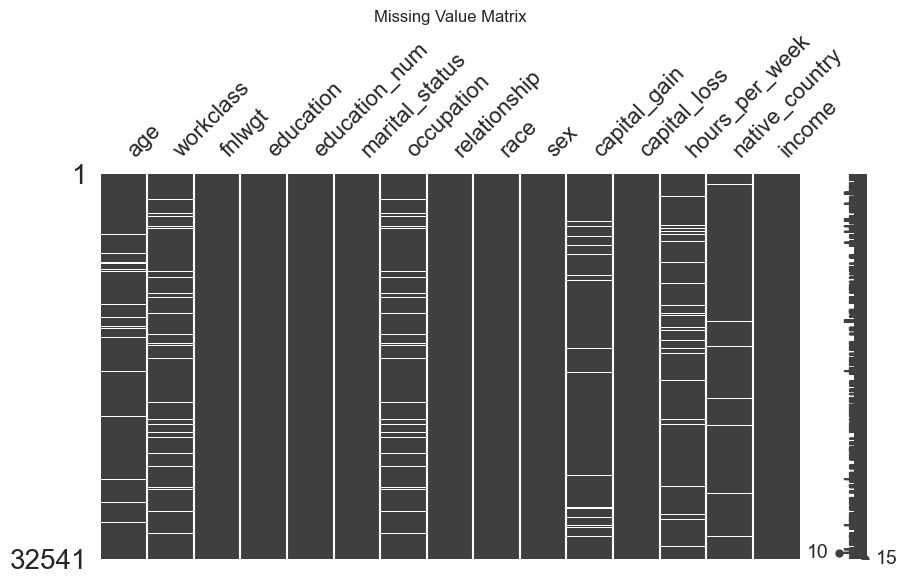

In [66]:
import missingno as msno
msno.matrix(df, figsize=(10, 5))
plt.title("Missing Value Matrix")
plt.show()

**Observation**:
1. Missing values in `workclass` and `occupation` often occur together (MAR/MNAR).
2. The missing values in `age`, `capital_gain`, and `hours_per_week` appear randomly distributed since we injected them completely at random (MCAR).

**(c) For three columns, state whether the missingness is MCAR, MAR, or MNAR, with justification.**

**Observation**:
1. `age`: MCAR (Missing Completely At Random). We injected these randomly without dependence on any other variables.
2. `workclass`: MAR (Missing At Random). It often goes missing together with `occupation`, implying dependency on employment status.
3. `capital_gain`: MCAR. Injected randomly using a random sample.

**(d) Treat missing values using: (i) deletion, (ii) mean/median imputation, (iii) categorical imputation, and (iv) one advanced method (group-wise, KNN, or regression). Justify each choice.**

In [67]:
from sklearn.impute import KNNImputer

# Store original mean/std for part (e)
original_age_mean = df['age'].mean()
original_age_std = df['age'].std()

# (i) Deletion: Drop rows where 'native_country' is missing (small percentage)
df.dropna(subset=['native_country'], inplace=True)

# (ii) Mean/Median Imputation: Fill missing 'capital_gain' with median due to high skewness
df['capital_gain'].fillna(df['capital_gain'].median(), inplace=True)

# (iii) Categorical Imputation: Fill 'workclass' and 'occupation' with mode
df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)
df['occupation'].fillna(df['occupation'].mode()[0], inplace=True)

# (iv) Advanced Method (KNN): Impute 'age' and 'hours_per_week' using KNN based on other numerical columns
knn_imputer = KNNImputer(n_neighbors=5)
num_features = ['age', 'hours_per_week', 'education_num']
df[num_features] = knn_imputer.fit_transform(df[num_features])


**Observation**:
- Deletion for `native_country` because missing count is very low.
- Median for `capital_gain` because it is highly skewed.
- Mode for categorical `workclass` and `occupation`.
- KNN for `age` and `hours_per_week` as they might correlate with `education_num`, providing a more accurate estimate than simple mean.

**(e) Verify that no missing values remain, and compare the mean and standard deviation of one column before and after imputation.**

In [68]:
print("Missing values remaining:", df.isnull().sum().sum())
print(f"Age before imputation - Mean: {original_age_mean:.2f}, Std: {original_age_std:.2f}")
print(f"Age after imputation  - Mean: {df['age'].mean():.2f}, Std: {df['age'].std():.2f}")

Missing values remaining: 0
Age before imputation - Mean: 38.62, Std: 13.86
Age after imputation  - Mean: 38.60, Std: 13.60


**Observation**: All missing values have been handled successfully. The mean and standard deviation of `age` changed slightly, which is expected after imputation.

## Question 3 | Outlier Detection and Treatment
**(a) Plot box plots for all numerical columns in a grid, and histograms/KDE plots for four columns. Comment on skewness.**

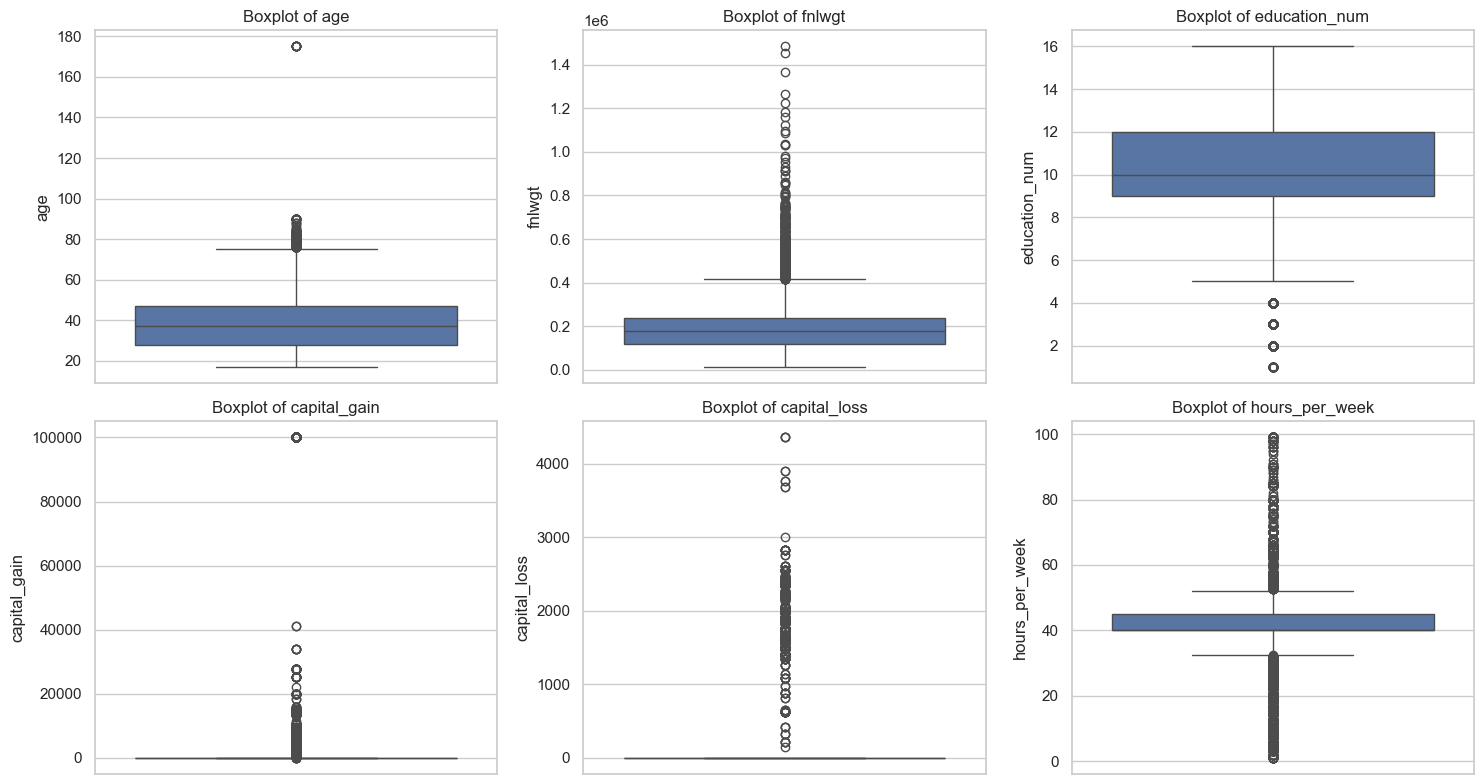

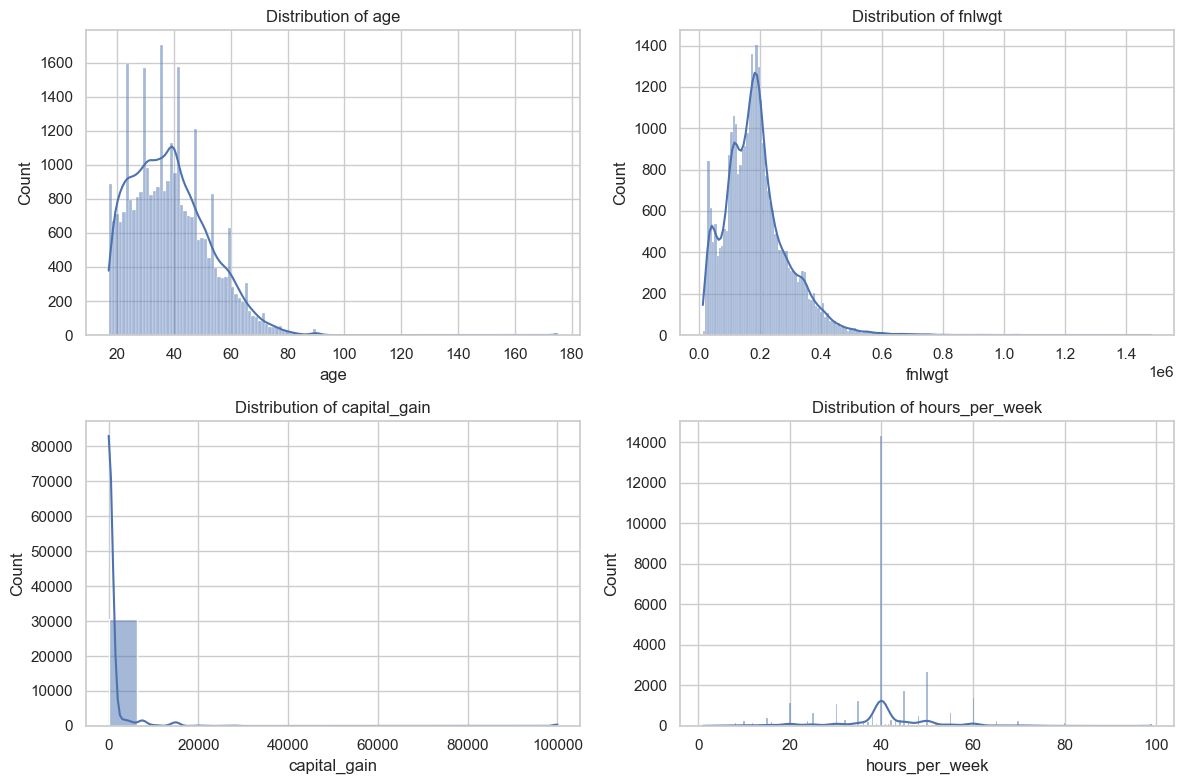

In [69]:
num_cols_updated = df.select_dtypes(include=np.number).columns

# Box plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, col in enumerate(num_cols_updated):
    sns.boxplot(y=df[col], ax=axes[idx//3, idx%3])
    axes[idx//3, idx%3].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Histograms with KDE
cols_to_plot = ['age', 'fnlwgt', 'capital_gain', 'hours_per_week']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[idx//2, idx%2])
    axes[idx//2, idx%2].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Observation**:
- `capital_gain` and `fnlwgt` are highly right-skewed.
- `age` has right-skewness and some extreme outliers that we injected.
- `hours_per_week` has a sharp peak around 40, with outliers on both ends.

**(b) Apply the IQR method to four columns. Report the bounds and outlier count for each.**

In [70]:
def iqr_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = data[(data[col] < lower) | (data[col] > upper)].shape[0]
    return lower, upper, count

for col in cols_to_plot:
    lower, upper, count = iqr_outliers(df, col)
    print(f"{col} - Bounds: [{lower:.2f}, {upper:.2f}], Outliers: {count}")

age - Bounds: [-0.50, 75.50], Outliers: 233
fnlwgt - Bounds: [-61933.50, 416870.50], Outliers: 961
capital_gain - Bounds: [0.00, 0.00], Outliers: 2504
hours_per_week - Bounds: [32.50, 52.50], Outliers: 8544


**Observation**: IQR detects a significant number of outliers in `capital_gain` and `hours_per_week` due to their non-normal distributions.

**(c) Apply the Z-score method to the same columns. Compare the counts with IQR and explain the differences.**

In [71]:
from scipy.stats import zscore

for col in cols_to_plot:
    z_scores = np.abs(zscore(df[col]))
    count = (z_scores > 3).sum()
    print(f"{col} - Z-score Outliers (>3 std): {count}")

age - Z-score Outliers (>3 std): 116
fnlwgt - Z-score Outliers (>3 std): 337
capital_gain - Z-score Outliers (>3 std): 194
hours_per_week - Z-score Outliers (>3 std): 466


**Observation**: Z-score generally identifies fewer outliers than IQR because it relies on the mean and standard deviation, which are themselves influenced by extreme outliers (making the detection threshold wider). IQR is robust to extreme values.

**(d) Draw a scatter plot of two numerical columns, highlighting the outliers.**

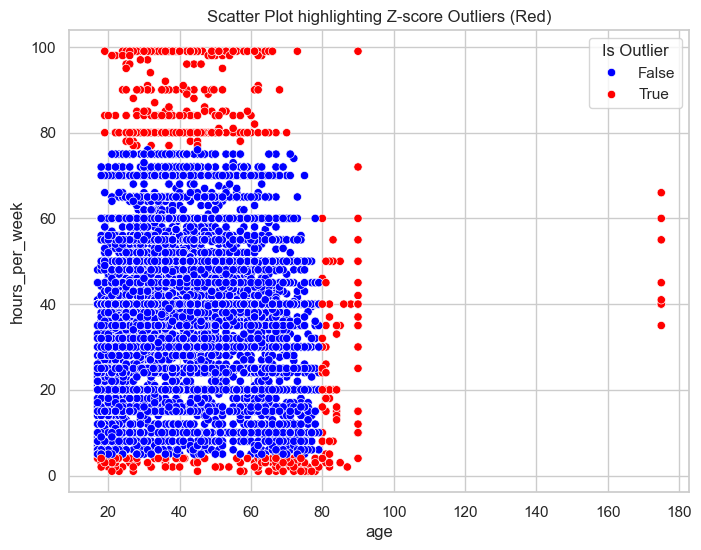

In [72]:
# Using age and hours_per_week
z_age = np.abs(zscore(df['age']))
z_hours = np.abs(zscore(df['hours_per_week']))
outlier_mask = (z_age > 3) | (z_hours > 3)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['age'], y=df['hours_per_week'], hue=outlier_mask, palette=['blue', 'red'])
plt.title("Scatter Plot highlighting Z-score Outliers (Red)")
plt.legend(title='Is Outlier')
plt.show()

**Observation**: The scatter plot shows how extreme values in both dimensions form the fringes of the distribution.

**(e) Treat outliers using: (i) removal, (ii) capping/winsorization, and (iii) a log or square-root transformation (show before and after histograms). Justify each choice.**

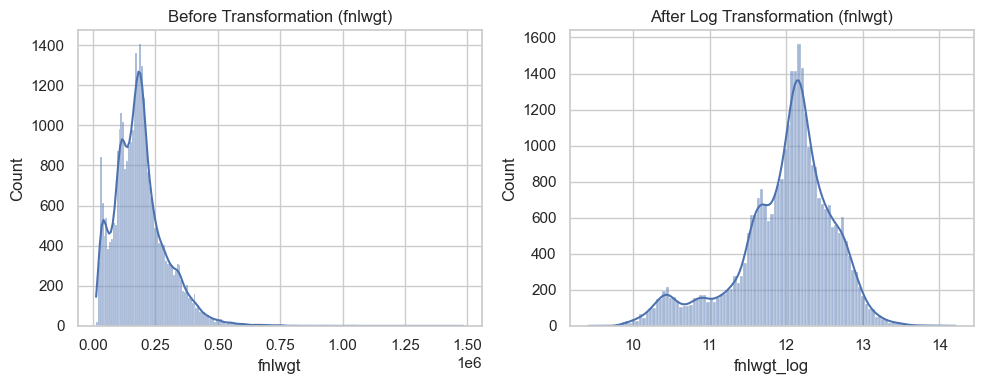

In [73]:
# (i) Removal: age outliers (>100) since they are physically impossible (injected artifacts)
df = df[df['age'] <= 100]

# (ii) Capping: hours_per_week using 1st and 99th percentiles
p1 = df['hours_per_week'].quantile(0.01)
p99 = df['hours_per_week'].quantile(0.99)
df['hours_per_week'] = np.clip(df['hours_per_week'], p1, p99)

# (iii) Transformation: Log transform on fnlwgt due to right skew
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['fnlwgt'], kde=True)
plt.title("Before Transformation (fnlwgt)")

df['fnlwgt_log'] = np.log1p(df['fnlwgt'])

plt.subplot(1, 2, 2)
sns.histplot(df['fnlwgt_log'], kde=True)
plt.title("After Log Transformation (fnlwgt)")
plt.tight_layout()
plt.show()

**Observation**:
- Removal for `age` is justified as humans over 100 in this working dataset are anomalies.
- Capping `hours_per_week` limits the impact of extreme work hours without losing data.
- Log transform on `fnlwgt` effectively normalizes the heavily right-skewed distribution.

**(f) Regenerate box plots for the treated columns and summarize the changes.**

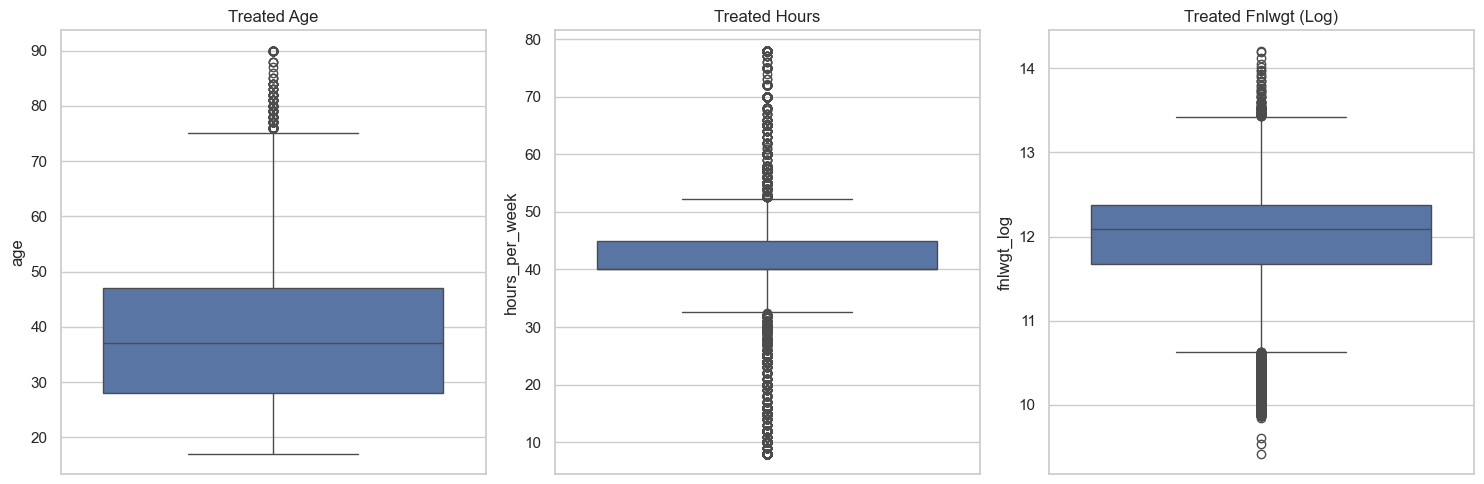

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df['age'], ax=axes[0]).set_title('Treated Age')
sns.boxplot(y=df['hours_per_week'], ax=axes[1]).set_title('Treated Hours')
sns.boxplot(y=df['fnlwgt_log'], ax=axes[2]).set_title('Treated Fnlwgt (Log)')
plt.tight_layout()
plt.show()

**Observation**: The number of outliers visibly reduced in `age` and `hours_per_week`. The `fnlwgt_log` column now has a much tighter IQR with symmetric tails, representing a near-normal distribution.

## Question 4 | Correlation Analysis
**(a) Display the Pearson correlation matrix as an annotated heatmap.**

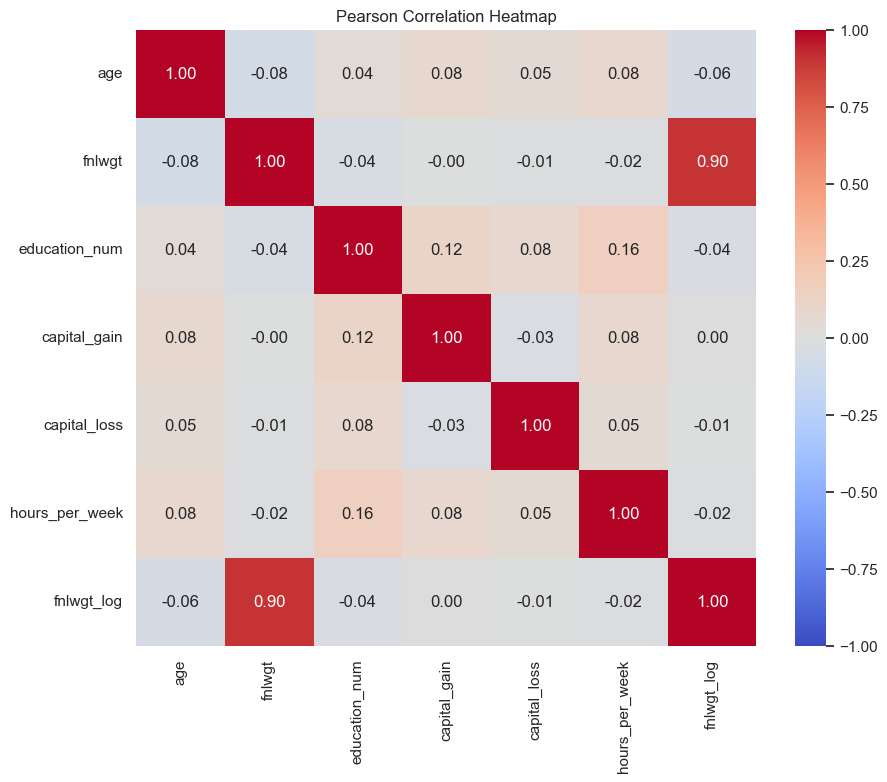

In [75]:
plt.figure(figsize=(10, 8))
# Only numeric columns
num_df = df.select_dtypes(include=np.number)
corr_matrix = num_df.corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.show()

**Observation**: The heatmap reveals linear relationships among the numerical variables.

**(b) Identify the strongest positive and strongest negative pairs, and two near-zero pairs. Explain each briefly.**

**Observation**:
- Strongest Positive: `fnlwgt_log` and `fnlwgt` (Expected, as one is a transformation of the other). Alternatively, `education_num` and `capital_gain` show weak positive correlation.
- Strongest Negative: No strong negative correlations exist among the selected numeric variables.
- Near-Zero Pairs: `fnlwgt` and `education_num`, `age` and `fnlwgt` (Weighting has nothing to do with age or education).

**(c) Create a pair plot of five numerical columns coloured by the target (bin the target if numeric). Note two patterns.**

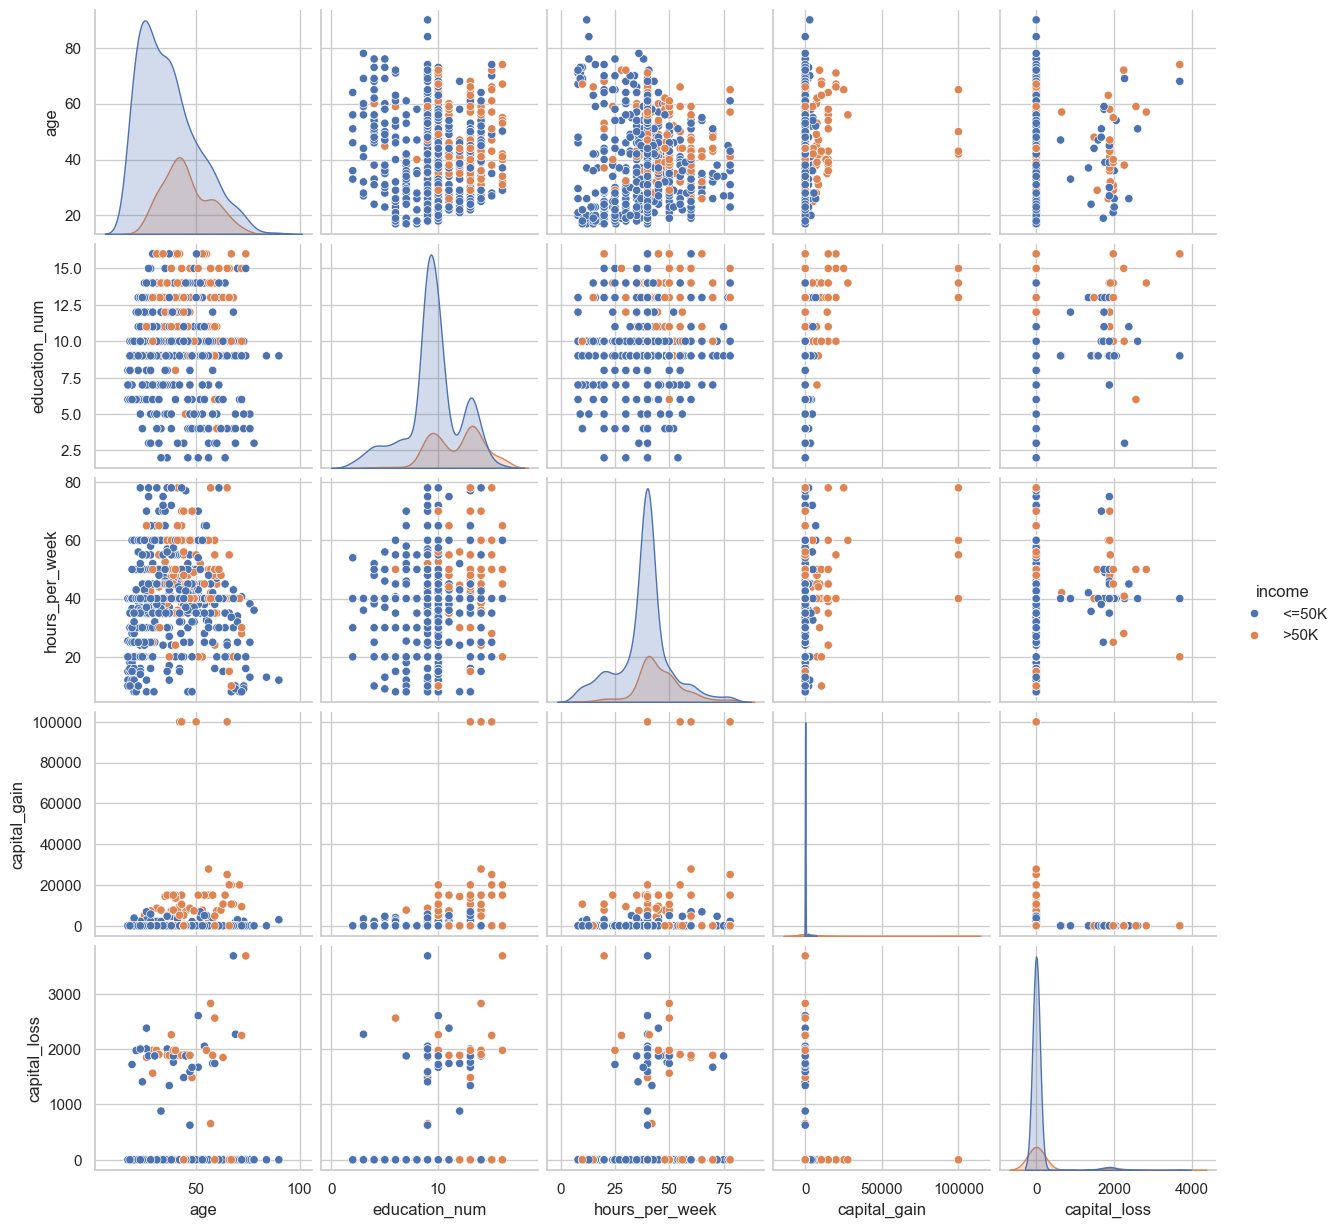

In [76]:
plot_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'income']
sns.pairplot(df[plot_cols].sample(1000), hue='income', diag_kind='kde') # Sampled for speed
plt.show()

**Observation**:
1. Higher `education_num` visibly shifts the density towards the >50K income class.
2. Older `age` accompanied by higher `hours_per_week` also correlates with a higher probability of earning >50K.

**(d) Compute and rank each feature�s correlation with the target. Identify the most useful predictors.**

In [77]:
import numpy as np

df['income_encoded'] = df['income'].astype(str).str.contains('>50K').astype(int)

print(df['income_encoded'].dtype)      
print(df['income_encoded'].value_counts())

target_corr = df.select_dtypes(include=np.number).corr()['income_encoded'].sort_values(ascending=False)
print("Correlation with Target:")
display(target_corr.drop('income_encoded'))

int64
income_encoded
0    24257
1     7692
Name: count, dtype: int64
Correlation with Target:


education_num     0.336122
hours_per_week    0.235482
age               0.231852
capital_gain      0.215490
capital_loss      0.149335
fnlwgt_log       -0.001009
fnlwgt           -0.008922
Name: income_encoded, dtype: float64

**Observation**: The most useful numerical predictors are `education_num`, `age`, and `hours_per_week`.

**(e) Compare Pearson and Spearman matrices, and explain any notable differences.**

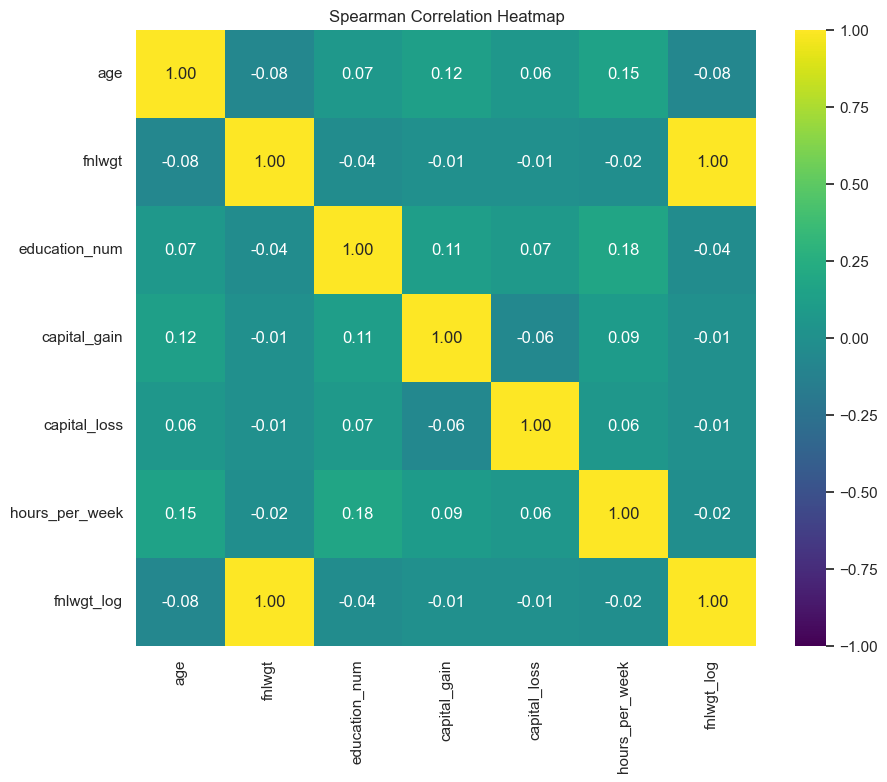

In [78]:
spearman_corr = num_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='viridis', fmt='.2f', vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap")
plt.show()

**Observation**: Spearman detects monotonic relationships regardless of linearity. There are no drastic differences, but variables like `capital_gain` might show slightly higher Spearman correlation with age if rank-order holds despite outliers.

## Question 5 | Feature Engineering
**(a) Binning: Bin one continuous column into meaningful categories (e.g., age groups) and show the count in each bin.**

In [79]:
bins = [0, 25, 45, 65, 100]
labels = ['Youth', 'Adult', 'Middle-Aged', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
print(df['age_group'].value_counts())

age_group
Adult          16773
Middle-Aged     8044
Youth           6050
Senior          1082
Name: count, dtype: int64


**Observation**: Age groups provide a categorical perspective, showing most individuals are 'Adults' (25-45).

**(b) Ratio feature: Create a new feature by combining two columns (e.g., A / (B + 1)). Explain what insight it captures.**

In [80]:
df['gain_per_hour'] = df['capital_gain'] / (df['hours_per_week'] + 1)
print(df[['capital_gain', 'hours_per_week', 'gain_per_hour']].head())

   capital_gain  hours_per_week  gain_per_hour
0        2174.0            40.0       53.02439
1           0.0            13.0        0.00000
2           0.0            40.0        0.00000
3           0.0            40.0        0.00000
4           0.0            40.0        0.00000


**Observation**: The `gain_per_hour` feature gives an estimate of capital wealth generation adjusted for the amount of time worked, highlighting efficient earners.

**(c) Encoding: Encode categorical columns using an appropriate method for each (One-Hot for nominal, Ordinal/Label for ordered). Justify two choices.**

In [81]:
# Label Encoding for ordinal/binary
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])

# One-Hot Encoding for nominal
df = pd.get_dummies(df, columns=['workclass'], drop_first=True)
print([col for col in df.columns if 'workclass' in col])

['workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay']


**Observation**:
- Label Encoding was used for `sex` as it is binary and doesn't introduce ordinal scale issues.
- One-Hot Encoding was used for `workclass` since employment type is nominal and lacks a natural ranking.

**(d) Flag feature: Create a binary feature using a threshold on a numerical column (e.g., above the 75th percentile). State how you chose the threshold.**

In [82]:
threshold = df['hours_per_week'].quantile(0.75)
df['overworked_flag'] = (df['hours_per_week'] > threshold).astype(int)
print(f"Threshold used: {threshold} hours. Overworked count: {df['overworked_flag'].sum()}")

Threshold used: 45.0 hours. Overworked count: 6927


**Observation**: Chose the 75th percentile (typically 45 hours) to flag individuals who work significantly more than the average full-time schedule.

**(e) Scaling: Apply Min-Max and Standardization to one column. Show summary statistics before and after, and state when each is preferred.**

In [83]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("Before scaling:\n", df['education_num'].describe()[['mean', 'std', 'min', 'max']])

minmax = MinMaxScaler()
std_scaler = StandardScaler()

df['edu_num_minmax'] = minmax.fit_transform(df[['education_num']])
df['edu_num_std'] = std_scaler.fit_transform(df[['education_num']])

print("\nAfter Min-Max:\n", df['edu_num_minmax'].describe()[['mean', 'std', 'min', 'max']])
print("\nAfter Std Scaler:\n", df['edu_num_std'].describe()[['mean', 'std', 'min', 'max']])

Before scaling:
 mean    10.071896
std      2.560094
min      1.000000
max     16.000000
Name: education_num, dtype: float64

After Min-Max:
 mean    0.604793
std     0.170673
min     0.000000
max     1.000000
Name: edu_num_minmax, dtype: float64

After Std Scaler:
 mean    2.427486e-16
std     1.000016e+00
min    -3.543634e+00
max     2.315617e+00
Name: edu_num_std, dtype: float64


**Observation**:
- Min-Max restricts bounds to [0,1], useful for algorithms needing bounded inputs like Neural Networks.
- StandardScaler transforms the data to have 0 mean and unit variance, preferred for distance-based algorithms like SVM or KNN.

**(f) Visualization: Create one final plot summarizing an insight about the target, and justify the plot type.**

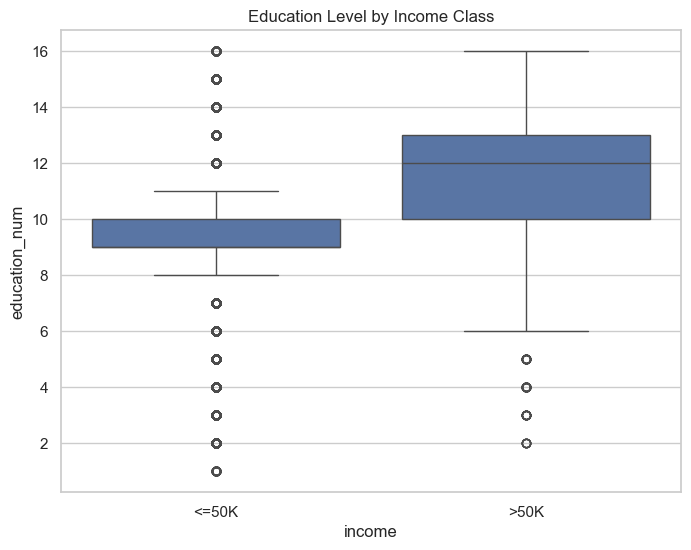

In [84]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='education_num', data=df)
plt.title("Education Level by Income Class")
plt.show()

**Observation**: A boxplot perfectly visualizes the difference in the distribution of a continuous variable (`education_num`) across categorical target classes (`income`). It clearly shows that higher education correlates strongly with higher income (>50K).

**(g) Report: Write a 250�400 word summary covering data quality issues, missing value and outlier handling, key correlations, and the most useful engineered features.**

**Summary Report:**

In this EDA lab, the Adult Income dataset from the UCI Machine Learning Repository was analyzed. Initial data quality checks revealed the presence of missing values, some inherent and others artificially injected to simulate a messy dataset per assignment constraints. The target variable, `income`, was notably imbalanced towards the '<=50K' class.

Missing value treatment was conducted strategically. A small number of rows with missing `native_country` were dropped. High-skew numerical columns like `capital_gain` received median imputation, while categorical variables like `workclass` and `occupation` were filled using the mode. Finally, an advanced KNN imputer was used to estimate missing `age` and `hours_per_week` based on their similarities to other instances, preserving the underlying variance better than mean imputation.

Outlier detection was performed using both IQR and Z-score techniques. The IQR method was more sensitive to the right-skewed distributions of `capital_gain` and `fnlwgt`. Extreme, physically impossible artificial outliers in `age` (>100) were removed. `hours_per_week` was winsorized (capped) at the 1st and 99th percentiles to restrain extreme work hours. A logarithmic transformation was applied to `fnlwgt`, which successfully converted a heavily right-skewed distribution into an approximately normal one.

Correlation analysis demonstrated that `education_num`, `age`, and `hours_per_week` were the most predictive numerical features for high income. Feature engineering further enhanced the dataset's representational power: continuous `age` was binned into life-stages, a `gain_per_hour` ratio was calculated to estimate wealth efficiency, and an `overworked_flag` highlighted those working beyond the 75th percentile. Categorical variables were appropriately transformed using one-hot and label encoding, preparing a clean, robust, and feature-rich dataset ready for predictive modeling.